# Slice-by-slice semantic annotation — Synchrotron CT (Paganin)

This notebook annotates a 3-D TIFF stack (one file per z-slice) from a synchrotron
CT acquisition using Paganin phase retrieval.  Each slice is a 2-D `float32` greyscale
image.  The workflow mirrors the existing IF/Xenium annotation approach:

1. Point to the TIFF stack directory and configure class labels
2. Choose a slice index to annotate
3. Load the slice → normalise to `uint16` → wrap as a single-channel `SpatialData` image
4. Open napari and draw polygons (Option B — shapes annotation)
5. Rasterize polygons → integer label mask
6. Save the mask (`.npy`) and shapes (`.parquet`) per slice
7. Repeat for additional slices

> **Tip:** Re-run cells 3 onwards for each new slice.  Previously saved masks are
> not overwritten unless `OVERWRITE = True`.

## 1. Imports

In [1]:
%gui qt

from __future__ import annotations

import numpy as np
import tifffile
import spatialdata
from spatialdata.models import Image2DModel

from napari_spatial_data import (
    run_annotation_session,
    rasterize_shapes_to_labels,
    get_scale0_shape,
    print_sdata_summary,
)

c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  inner = partial(_inner_join_spatialelement_table)
c:\Users\

## 2. Configuration

Set the path to the TIFF stack, the output directory, and the semantic class labels.
Adjust `CLASS_LABELS` to match the anatomy visible in your sample.

In [2]:
# ── Input ────────────────────────────────────────────────────────────────────
STACK_DIR = Path("F:/mg30542/14W A2/14W A2 DIP 4x/paganin50/14W_A2_DIP_4x_180_paganin50")
SAMPLE_ID = "14W_A2_DIP_4x_paganin50"   # used in output filenames

# ── Output ───────────────────────────────────────────────────────────────────
OUT_DIR = PROJECT_ROOT / "notebooks" / "synchrotron" / "data"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OVERWRITE = False   # set True to re-annotate a slice that already has a saved mask

# ── SpatialData element keys ─────────────────────────────────────────────────
IMAGE_KEY          = "paganin_slice"
SHAPES_KEY         = "shapes_semantic"
LABELS_KEY         = "labels_from_shapes"

# ── Semantic classes ─────────────────────────────────────────────────────────
CLASS_LABELS = {
    1:  "artefact",
    2:  "epidermis",
    3:  "dermis",
    4:  "nail_matrix",
    5:  "adipose_tissue",
    6:  "bone",
    7:  "cartilage",
    8:  "vascular_structure",
    9:  "dense_regular_connective_tissue",
    10: "muscle",
    11: "annotated background",
    12: "synovial_cavity",
    13: "bone_marrow",
    14: "loose_connective_tissue",
    15: "dense_irregular_connective_tissue"
}

# ── Physical pixel size (used for scale bar) ────────────────────────────────────────
PIXEL_SIZE_UM = 1   # µm per pixel at full resolution (scale0); adjust to your setup

# ── Collect and sort slice files ─────────────────────────────────────────────
SLICE_FILES = sorted(STACK_DIR.glob("img_*.tiff"))
N_SLICES    = len(SLICE_FILES)

print(f"Stack directory : {STACK_DIR}")
print(f"Total slices    : {N_SLICES}")
print(f"Output directory: {OUT_DIR}")
print(f"Classes         : {CLASS_LABELS}")

Stack directory : F:\mg30542\14W A2\14W A2 DIP 4x\paganin50\14W_A2_DIP_4x_180_paganin50
Total slices    : 2160
Output directory: C:\Users\mcowan\Documents\napari_spatial_data\notebooks\synchrotron\data
Classes         : {1: 'artefact', 2: 'epidermis', 3: 'dermis', 4: 'nail_matrix', 5: 'adipose_tissue', 6: 'bone', 7: 'cartilage', 8: 'vascular_structure', 9: 'dense_regular_connective_tissue', 10: 'muscle', 11: 'annotated background', 12: 'synovial_cavity', 13: 'bone_marrow', 14: 'loose_connective_tissue', 15: 'dense_irregular_connective_tissue'}


## 3. Inspect the stack

Quick sanity-check of dtype, shape, and value range across a few representative slices.

In [3]:
probe_indices = [0, N_SLICES // 4, N_SLICES // 2, 3 * N_SLICES // 4, N_SLICES - 1]

print(f"{'Slice':>6}  {'Shape':>12}  {'dtype':>8}  {'min':>10}  {'max':>10}")
print("-" * 56)
for idx in probe_indices:
    img = tifffile.imread(SLICE_FILES[idx])
    print(f"{idx:>6}  {str(img.shape):>12}  {str(img.dtype):>8}  {img.min():>10.4f}  {img.max():>10.4f}")

 Slice         Shape     dtype         min         max
--------------------------------------------------------
     0  (2560, 2560)   float32     -0.0217      0.0235
   540  (2560, 2560)   float32     -0.0005      0.0066
  1080  (2560, 2560)   float32     -0.0054      0.0087
  1620  (2560, 2560)   float32     -0.0063      0.0109
  2159  (2560, 2560)   float32     -0.0311      0.0295


## 4. Choose a slice to annotate

Set `SLICE_IDX` to the z-index of the slice you want to work on.  Re-run this cell
(and all cells below) for each new slice.

In [20]:
SLICE_IDX = 540   # ← change this for each slice

slice_file = SLICE_FILES[SLICE_IDX]
print(f"Slice {SLICE_IDX:04d}: {slice_file.name}")

# Output paths for this slice
mask_path   = OUT_DIR / f"{SAMPLE_ID}_slice{SLICE_IDX:04d}_labels_from_shapes.npy"
shapes_path = OUT_DIR / f"{SAMPLE_ID}_slice{SLICE_IDX:04d}_shapes_semantic.parquet"

if mask_path.exists() and not OVERWRITE:
    print(f"\n⚠  Mask already exists at {mask_path}")
    print("   Set OVERWRITE = True (cell 2) and re-run to replace it.")
else:
    print(f"\nOutput mask   : {mask_path}")
    print(f"Output shapes : {shapes_path}")

Slice 0540: img_145811_00540.tiff

Output mask   : C:\Users\mcowan\Documents\napari_spatial_data\notebooks\synchrotron\data\14W_A2_DIP_4x_paganin50_slice0540_labels_from_shapes.npy
Output shapes : C:\Users\mcowan\Documents\napari_spatial_data\notebooks\synchrotron\data\14W_A2_DIP_4x_paganin50_slice0540_shapes_semantic.parquet


## 5. Load the slice and build a SpatialData object

The raw Paganin image is `float32` with values near zero (phase-map units).  We
normalise to `uint16` for display in napari while preserving the full dynamic range.
The original `float32` array is kept separately for any downstream processing.

In [21]:
# Load raw float32 slice
img_f32 = tifffile.imread(slice_file)     # (H, W), float32
H, W = img_f32.shape
print(f"Loaded: {slice_file.name}  shape={img_f32.shape}  dtype={img_f32.dtype}")
print(f"Value range: [{img_f32.min():.4f}, {img_f32.max():.4f}]")

# Normalise to uint16 for display
vmin, vmax = img_f32.min(), img_f32.max()
img_u16 = ((img_f32 - vmin) / (vmax - vmin) * 65535).astype(np.uint16)  # (H, W)

# Wrap as single-channel SpatialData image: (c=1, y=H, x=W)
image = Image2DModel.parse(
    img_u16[np.newaxis],          # add channel dim
    dims=["c", "y", "x"],
    c_coords=["paganin"],
    scale_factors=[2, 2],         # full → ½ → ¼  (lazy pyramid, no extra RAM)
)

sdata = spatialdata.SpatialData(images={IMAGE_KEY: image})
print()
print_sdata_summary(sdata)

Loaded: img_145811_00540.tiff  shape=(2560, 2560)  dtype=float32
Value range: [-0.0005, 0.0066]

SpatialData summary

[images]
  'paganin_slice'                → {'c': 1, 'y': 2560, 'x': 2560}


C:\Users\mcowan\Documents\napari_spatial_data\sdata_utils.py:214: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  shape = dict(element["scale0"].ds.dims)  # multiscale


## 6. Annotate in napari (polygon / shapes mode)

1. A napari window will open with the Paganin slice loaded as a greyscale image.
2. Select the **Shapes** layer in the layer list.
3. Draw polygons around regions of interest using the toolbar tools.
4. After each polygon, press **T** (or click *Tag last polygon*) and choose the class ID.
5. **Close the viewer** when finished — shapes are automatically stored in `sdata`.

> Use the **contrast limits** slider to brighten dim features — the Paganin phase
> range is narrow but the normalised `uint16` image maps it linearly.

In [22]:
run_annotation_session(
    sdata,
    image_key=IMAGE_KEY,
    mode="shapes",
    shapes_element_name=SHAPES_KEY,
    labels_element_name=LABELS_KEY,
    scale_factors=[2, 2, 2, 2],
    class_labels=CLASS_LABELS,
)

if SHAPES_KEY in sdata.shapes:
    n = len(sdata.shapes[SHAPES_KEY])
    classes = sorted(sdata.shapes[SHAPES_KEY]["class_id"].unique().tolist())
    print(f"\nStored {n} polygon(s), classes present: {classes}")
    print(sdata.shapes[SHAPES_KEY][["class_id", "geometry"]].head())
else:
    print("No shapes drawn — close napari and re-run this cell to try again.")


[napari] Draw polygons/rectangles on the image.
After each polygon: press T (or click 'Tag last polygon') to
assign the current class ID, then draw the next polygon.
Close the viewer when done.

No shapes drawn — close napari and re-run this cell to try again.


c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\vispy\geometry\triangulation.py:720: RuntimeWarning: overflow encountered in multiply
  f = (l2 * p).sum(axis=-1)  # l2 dot p
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Stored 'shapes_semantic' in sdata.shapes  (n_shapes=99, classes=[2, 3, 4, 7, 8, 9, 11, 14])
Rasterized 'shapes_semantic' → 'labels_from_shapes'  (shape=(2560, 2560), unique classes=[0, 2, 3, 4, 7, 8, 9, 11, 14])


## 7. Rasterize shapes → integer label mask

`run_annotation_session` already rasterizes in shapes mode, but re-running
`rasterize_shapes_to_labels` here lets you regenerate the mask after editing
`class_id` values without reopening napari.

In [23]:
if SHAPES_KEY in sdata.shapes:
    rasterize_shapes_to_labels(
        sdata,
        shapes_key=SHAPES_KEY,
        image_key=IMAGE_KEY,
        element_name=LABELS_KEY,
        class_column="class_id",
        scale_factors=[2, 2],
    )

if LABELS_KEY in sdata.labels:
    labels_arr = sdata.labels[LABELS_KEY]["scale0"].ds["image"].values
    unique_classes = np.unique(labels_arr).tolist()
    print(f"Label mask shape : {labels_arr.shape}")
    print(f"Unique class IDs : {unique_classes}")
    print(f"  0 = unlabelled background")
    for cid, name in CLASS_LABELS.items():
        if cid in unique_classes:
            px = int((labels_arr == cid).sum())
            print(f"  {cid:>2} = {name:<40} {px:>10,} px")
else:
    print("No labels found — did annotation complete?")

Rasterized 'shapes_semantic' → 'labels_from_shapes'  (shape=(2560, 2560), unique classes=[0, 2, 3, 4, 7, 8, 9, 11, 14])
Label mask shape : (2560, 2560)
Unique class IDs : [0, 2, 3, 4, 7, 8, 9, 11, 14]
  0 = unlabelled background
   2 = epidermis                                   372,934 px
   3 = dermis                                    1,300,830 px
   4 = nail_matrix                                  93,826 px
   7 = cartilage                                   426,178 px
   8 = vascular_structure                           72,391 px
   9 = dense_regular_connective_tissue             390,865 px
  11 = annotated background                         18,810 px
  14 = loose_connective_tissue                     763,914 px


## 8. Quick visual check

Overlay the label mask on the normalised image using matplotlib — no napari required.

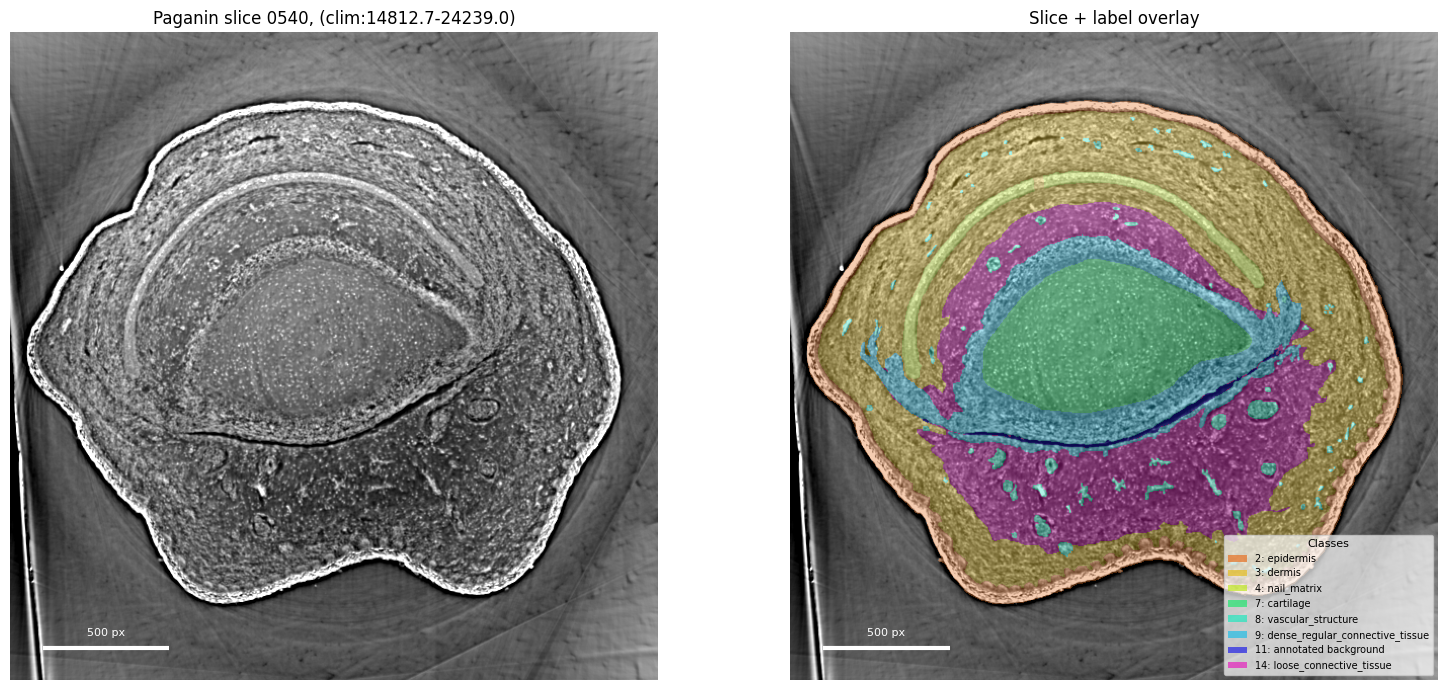

In [24]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from sdata_utils import class_id_colormap

if LABELS_KEY in sdata.labels:
    # Use a coarser scale for speed (scale2 = ¼ resolution)
    scale_key = "scale2" if "scale2" in sdata.labels[LABELS_KEY].keys() else "scale0"
    mask_small = sdata.labels[LABELS_KEY][scale_key].ds["image"].values

    # Downsample the display image to match
    img_key = "scale2" if "scale2" in sdata.images[IMAGE_KEY].keys() else "scale0"
    img_small = sdata.images[IMAGE_KEY][img_key].ds["image"].values[0]  # drop c dim

    # Effective pixel size at the displayed scale
    scale_factor = 4 if scale_key == "scale2" else 1  # scale2 → 2x2x2x2 = 16? depends on pyramid
    # Safer: infer from ratio of full-res vs displayed array
    full_h = sdata.images[IMAGE_KEY]["scale0"].ds["image"].values.shape[-2]
    disp_h = img_small.shape[0]
    downsample = full_h / disp_h
    px_um = sdata.attrs.get("pixel_size_um", PIXEL_SIZE_UM) * downsample

    # Build a transparent-background colormap for the overlay
    n_cls = max(CLASS_LABELS.keys())
    cmap_dict = class_id_colormap(n_cls)
    colors_list = [cmap_dict.get(i, (0, 0, 0, 0)) for i in range(n_cls + 1)]
    cmap = mcolors.ListedColormap(colors_list)
    norm = mcolors.BoundaryNorm(boundaries=range(n_cls + 2), ncolors=n_cls + 1)

    contrast_limits = sdata.attrs.get("contrast_limits", {})
    clim = contrast_limits.get("paganin")  # [low_u16, high_u16] already in uint16

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(img_small, cmap="gray", vmin=clim[0] if clim else None, vmax=clim[1] if clim else None)
    axes[0].set_title(f"Paganin slice {SLICE_IDX:04d}, (clim:{clim[0]:.1f}-{clim[1]:.1f})")
    axes[0].axis("off")

    axes[1].imshow(img_small, cmap="gray", vmin=clim[0] if clim else None, vmax=clim[1] if clim else None)
    axes[1].imshow(mask_small, cmap=cmap, norm=norm, alpha=0.5, interpolation="nearest")
    axes[1].set_title("Slice + label overlay")
    axes[1].axis("off")

    # ── Legend: only classes present in this mask ───────────────────────────
    import numpy as np
    present_ids = [cid for cid in np.unique(mask_small) if cid != 0 and cid in CLASS_LABELS]
    legend_handles = [
        mpatches.Patch(
            facecolor=cmap_dict[cid][:3],
            alpha=cmap_dict[cid][3],
            edgecolor="none",
            label=f"{cid}: {CLASS_LABELS[cid]}",
        )
        for cid in present_ids
    ]
    if legend_handles:
        axes[1].legend(
            handles=legend_handles,
            loc="lower right",
            fontsize=7,
            framealpha=0.7,
            title="Classes",
            title_fontsize=8,
        )

    # ── Scale bar ─────────────────────────────────────────────────────
    scalebar_um = 500  # desired scale bar length in µm
    scalebar_px = scalebar_um / px_um
    h, w = img_small.shape
    bar_x = w * 0.05          # left edge of bar (5 % from left)
    bar_y = h * 0.95          # vertical position  (95 % from top)
    axes[0].plot(
        [bar_x, bar_x + scalebar_px], [bar_y, bar_y],
        color="white", linewidth=3, solid_capstyle="butt",
    )
    axes[0].text(
        bar_x + scalebar_px / 2, bar_y - h * 0.015,
        f"{scalebar_um} px", #µm - microns not available for this sample rn
        color="white", fontsize=8, ha="center", va="bottom",
    )

    axes[1].plot(
        [bar_x, bar_x + scalebar_px], [bar_y, bar_y],
        color="white", linewidth=3, solid_capstyle="butt",
    )
    axes[1].text(
        bar_x + scalebar_px / 2, bar_y - h * 0.015,
        f"{scalebar_um} px", #µm - microns not available for this sample rn
        color="white", fontsize=8, ha="center", va="bottom",
    )

    plt.tight_layout()
    plt.show()
else:
    print("Nothing to preview yet.")


## 9. Save mask and shapes for this slice

In [25]:
import json

if LABELS_KEY not in sdata.labels or SHAPES_KEY not in sdata.shapes:
    print("Nothing to save — complete annotation first (cell 6).")
elif mask_path.exists() and not OVERWRITE:
    print(f"Skipping save — {mask_path.name} already exists. Set OVERWRITE=True to replace.")
else:
    # Save full-resolution label mask as numpy array
    labels_full = sdata.labels[LABELS_KEY]["scale0"].ds["image"].values
    np.save(mask_path, labels_full)
    print(f"Saved mask   → {mask_path}")

    # Save shapes as parquet (preserves class_id + geometry)
    sdata.shapes[SHAPES_KEY].to_parquet(shapes_path)
    print(f"Saved shapes → {shapes_path}")

    # Save the normalised uint16 image for reference
    img_ref_path = OUT_DIR / f"{SAMPLE_ID}_slice{SLICE_IDX:04d}_u16.npy"
    np.save(img_ref_path, img_u16)
    print(f"Saved image  → {img_ref_path}")

    # ── Save contrast limits chosen in napari ─────────────────────────────
    contrast_limits = sdata.attrs.get("contrast_limits", {})
    if contrast_limits:
        # Also record the float32 normalisation range used for this slice so
        # that downstream code can invert the uint16 → float32 mapping.
        meta = {
            "contrast_limits_u16": contrast_limits,   # {channel: [low, high]} in uint16
            "norm_vmin_f32": float(vmin),             # float32 min used during normalisation
            "norm_vmax_f32": float(vmax),             # float32 max used during normalisation
            "slice_idx": SLICE_IDX,
            "sample_id": SAMPLE_ID,
        }
        cl_path = OUT_DIR / f"{SAMPLE_ID}_slice{SLICE_IDX:04d}_contrast_limits.json"
        with open(cl_path, "w") as fh:
            json.dump(meta, fh, indent=2)
        print(f"Saved contrast limits → {cl_path}")

        # Summarise what was captured
        for ch, (lo, hi) in contrast_limits.items():
            # Convert uint16 [0,65535] → original float32 units for interpretability
            lo_f = vmin + (lo / 65535) * (vmax - vmin)
            hi_f = vmin + (hi / 65535) * (vmax - vmin)
            print(f"  {ch}: uint16 [{lo:.0f}, {hi:.0f}]  →  float32 [{lo_f:.5f}, {hi_f:.5f}]")
    else:
        print("⚠  No contrast limits captured — did napari close normally?")

Saved mask   → C:\Users\mcowan\Documents\napari_spatial_data\notebooks\synchrotron\data\14W_A2_DIP_4x_paganin50_slice0540_labels_from_shapes.npy
Saved shapes → C:\Users\mcowan\Documents\napari_spatial_data\notebooks\synchrotron\data\14W_A2_DIP_4x_paganin50_slice0540_shapes_semantic.parquet
Saved image  → C:\Users\mcowan\Documents\napari_spatial_data\notebooks\synchrotron\data\14W_A2_DIP_4x_paganin50_slice0540_u16.npy
Saved contrast limits → C:\Users\mcowan\Documents\napari_spatial_data\notebooks\synchrotron\data\14W_A2_DIP_4x_paganin50_slice0540_contrast_limits.json
  paganin: uint16 [14813, 24239]  →  float32 [0.00107, 0.00209]


## 9b. Apply the saved contrast window for model training

The contrast limits define a window `[lo_f32, hi_f32]` in original float32 units.
Applying this window before feeding slices to a model ensures the model sees the
same contrast the annotator used — critical when the Paganin dynamic range varies
between slices.

The helper below loads the JSON sidecar and returns a `float32` array clipped and
re-normalised to `[0, 1]` using that window, ready to feed into a network.

In [ ]:
import json
import numpy as np
import tifffile
from pathlib import Path


def load_windowed_slice(
    raw_f32: np.ndarray,
    cl_json_path: Path,
    channel: str = "paganin",
) -> np.ndarray:
    """
    Apply the napari contrast window to a raw Paganin float32 slice.

    Clips the image to [lo_f32, hi_f32] (the annotator's chosen window) and
    rescales to [0, 1] float32.  This is the normalisation the model should
    receive so it matches what the annotator saw.

    Parameters
    ----------
    raw_f32:
        Raw float32 slice array (H, W).
    cl_json_path:
        Path to the ``*_contrast_limits.json`` sidecar saved in cell 9.
    channel:
        Channel name key inside the JSON (default ``"paganin"``).

    Returns
    -------
    np.ndarray
        float32 array in [0, 1], same shape as raw_f32.
    """
    with open(cl_json_path) as fh:
        meta = json.load(fh)

    norm_vmin = meta["norm_vmin_f32"]
    norm_vmax = meta["norm_vmax_f32"]
    lo_u16, hi_u16 = meta["contrast_limits_u16"][channel]

    # Convert uint16 limits back to float32 units
    lo_f32 = norm_vmin + (lo_u16 / 65535.0) * (norm_vmax - norm_vmin)
    hi_f32 = norm_vmin + (hi_u16 / 65535.0) * (norm_vmax - norm_vmin)

    clipped = np.clip(raw_f32, lo_f32, hi_f32)
    windowed = (clipped - lo_f32) / (hi_f32 - lo_f32)
    return windowed.astype(np.float32)


# ── Demo: apply to the current slice ─────────────────────────────────────────
cl_path = OUT_DIR / f"{SAMPLE_ID}_slice{SLICE_IDX:04d}_contrast_limits.json"

if cl_path.exists():
    img_windowed = load_windowed_slice(img_f32, cl_path)
    print(f"Windowed image: dtype={img_windowed.dtype}  "
          f"range=[{img_windowed.min():.4f}, {img_windowed.max():.4f}]")
    print(f"  (values of 0.0 = lo_f32 limit, 1.0 = hi_f32 limit)")
else:
    print("No contrast limits JSON found — run cell 9 first.")

## 10. Batch summary — list all annotated slices

In [26]:
saved_masks = sorted(OUT_DIR.glob(f"{SAMPLE_ID}_slice*_labels_from_shapes.npy"))

if not saved_masks:
    print("No annotated slices saved yet.")
else:
    print(f"{'Slice':>6}  {'Shape':>14}  {'Classes':>30}  Path")
    print("-" * 90)
    for p in saved_masks:
        arr = np.load(p)
        # Extract slice index from filename
        import re
        m = re.search(r"slice(\d+)", p.name)
        idx_str = m.group(1) if m else "???"
        classes = [int(c) for c in np.unique(arr) if c != 0]
        print(f"{idx_str:>6}  {str(arr.shape):>14}  {str(classes):>30}  {p.name}")

 Slice           Shape                         Classes  Path
------------------------------------------------------------------------------------------
  0540    (2560, 2560)      [2, 3, 4, 7, 8, 9, 11, 14]  14W_A2_DIP_4x_paganin50_slice0540_labels_from_shapes.npy
  0720    (2560, 2560)      [2, 3, 4, 7, 8, 9, 11, 14]  14W_A2_DIP_4x_paganin50_slice0720_labels_from_shapes.npy
  0900    (2560, 2560)      [1, 2, 3, 7, 8, 9, 11, 14]  14W_A2_DIP_4x_paganin50_slice0900_labels_from_shapes.npy
  1080    (2560, 2560)     [2, 3, 7, 8, 9, 11, 14, 15]  14W_A2_DIP_4x_paganin50_slice1080_labels_from_shapes.npy
  1260    (2560, 2560)     [2, 3, 7, 8, 9, 11, 14, 15]  14W_A2_DIP_4x_paganin50_slice1260_labels_from_shapes.npy
  1440    (2560, 2560)  [1, 2, 3, 7, 8, 9, 11, 14, 15]  14W_A2_DIP_4x_paganin50_slice1440_labels_from_shapes.npy
  1620    (2560, 2560)         [2, 3, 7, 8, 9, 11, 14]  14W_A2_DIP_4x_paganin50_slice1620_labels_from_shapes.npy
  1800    (2560, 2560)         [2, 3, 7, 8, 9, 11, 14]  1

## 11. Annotate the next slice

Change `SLICE_IDX` in **cell 4**, then re-run cells 4 → 9 to annotate the next slice.
Each slice saves independently so you can annotate non-contiguously and resume at any time.

| Goal | How |
|---|---|
| Change brush / polygon tool | Use napari toolbar — polygon, rectangle, ellipse, etc. |
| Adjust contrast | Drag the *contrast limits* bar on the `paganin` image layer |
| Re-tag a shape | Select it, press **T** with the correct class in the spinbox |
| Load a saved mask | `np.load(mask_path)` — shape `(H, W)`, dtype `int32` |
| Load saved shapes | `import geopandas as gpd; gpd.read_parquet(shapes_path)` |
| Wrap masks into SpatialData | Use `sdata_utils.wrap_to_multiscale_labels` |

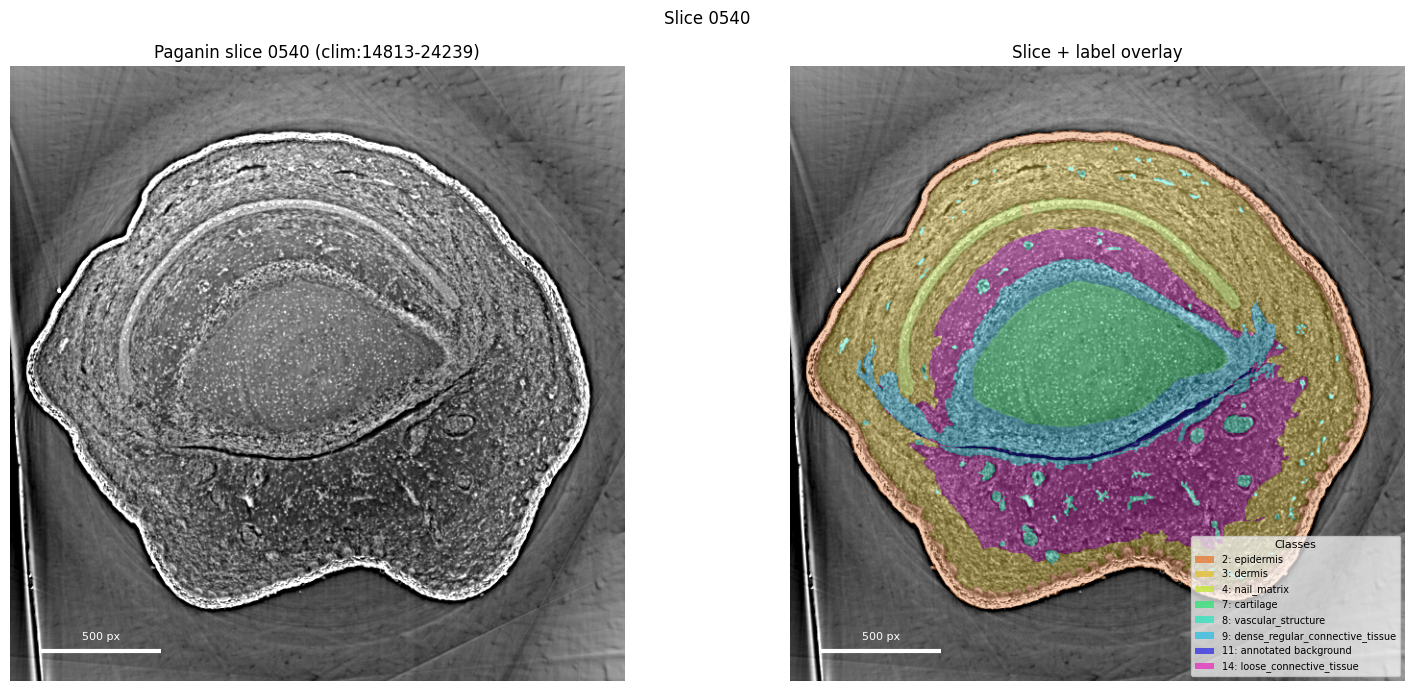

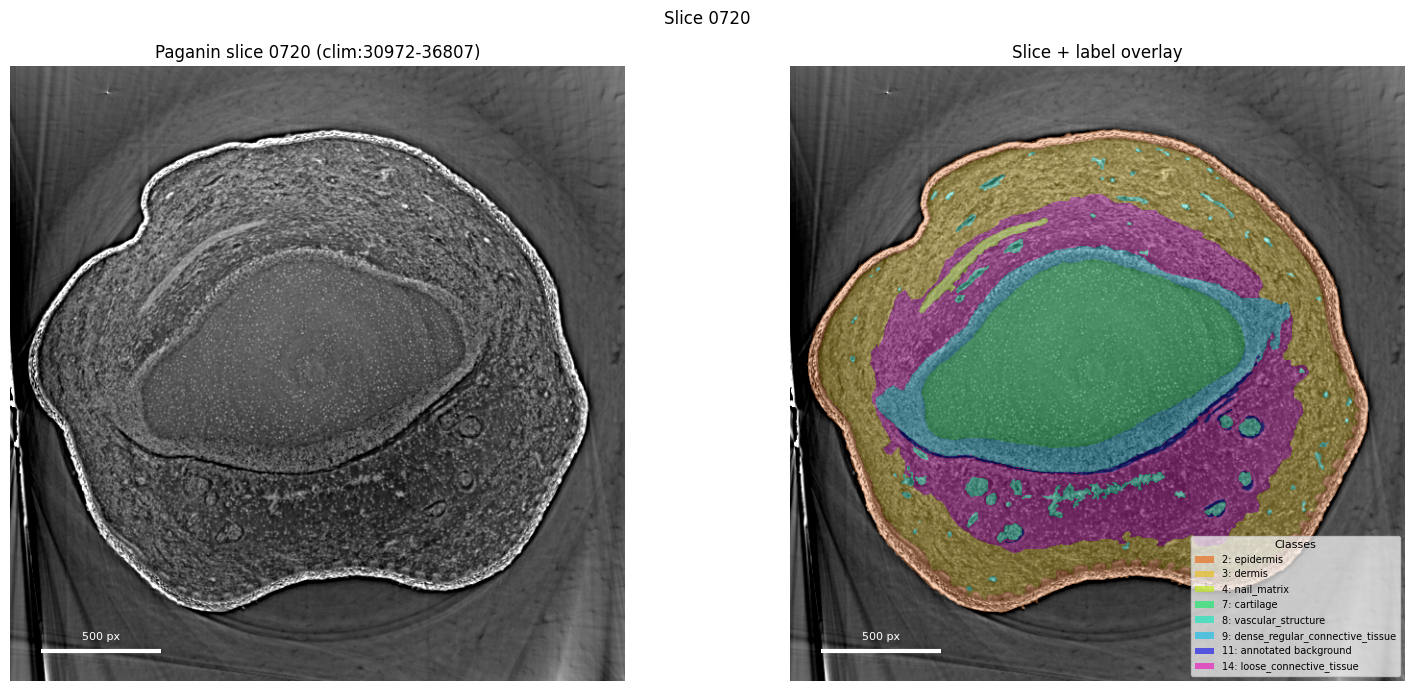

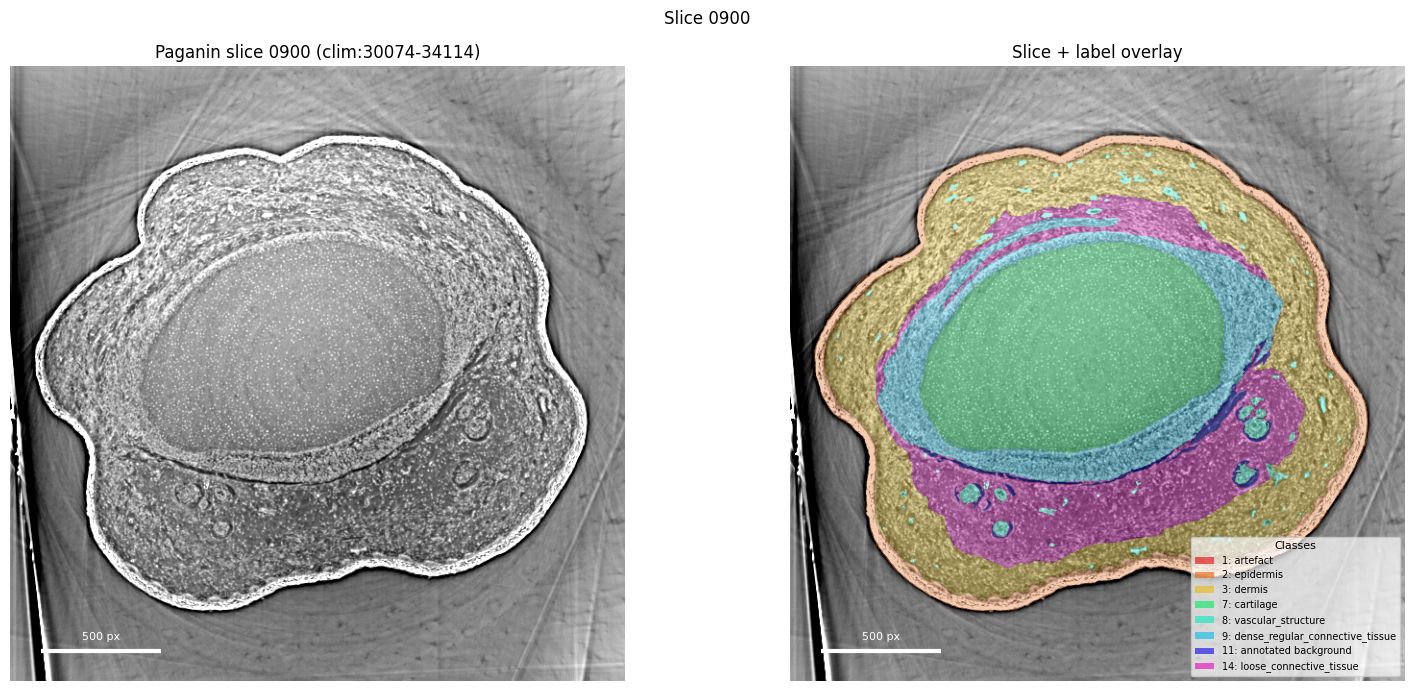

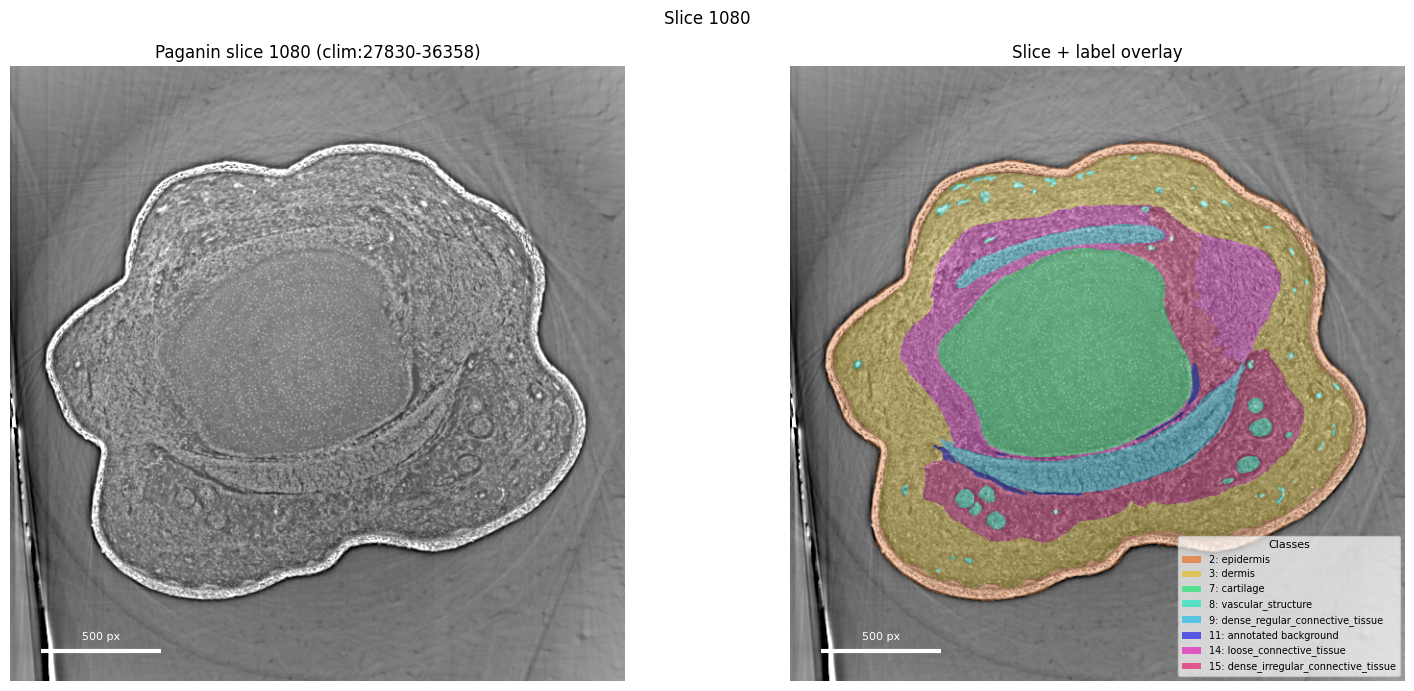

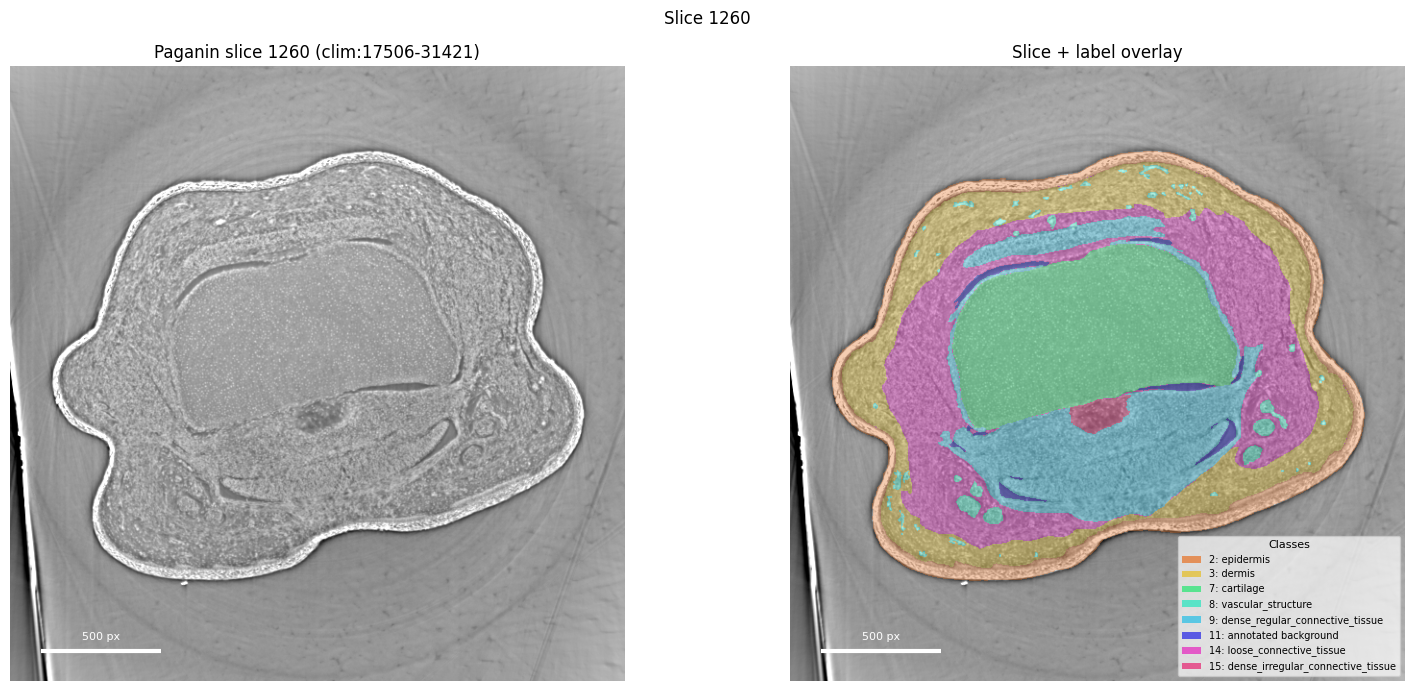

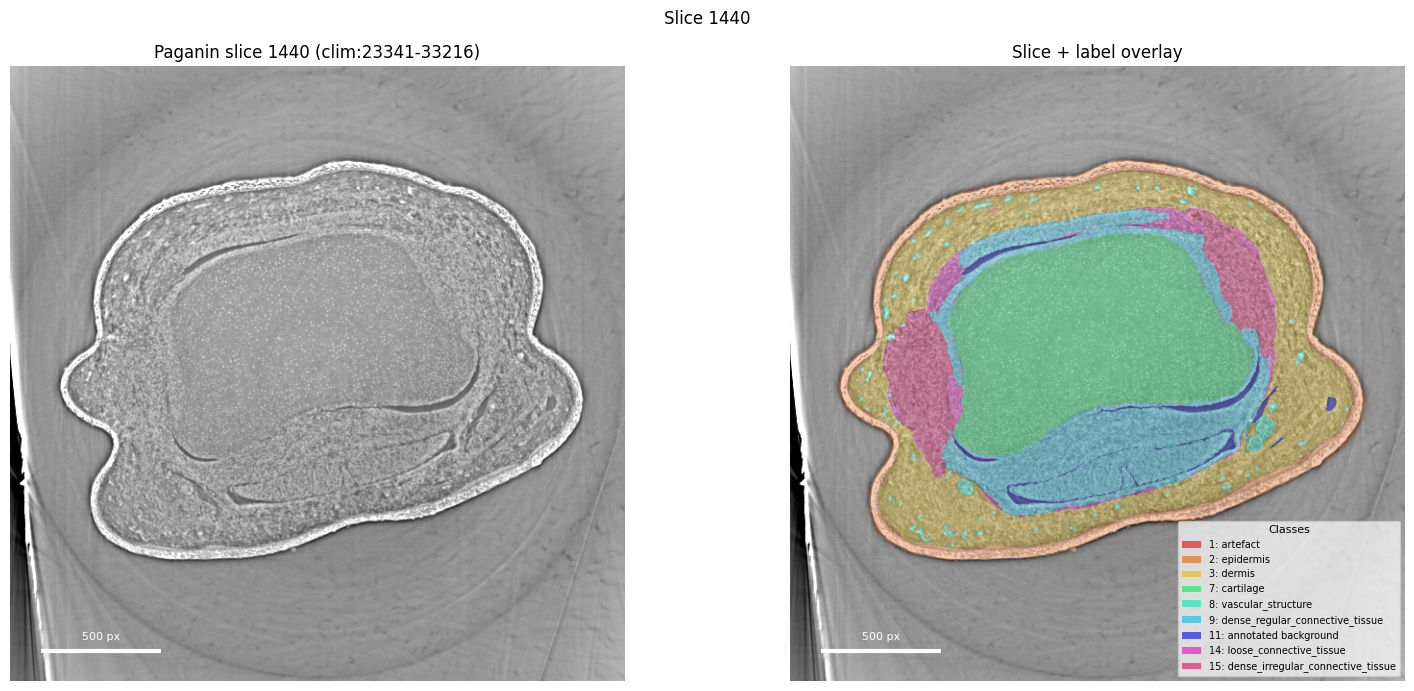

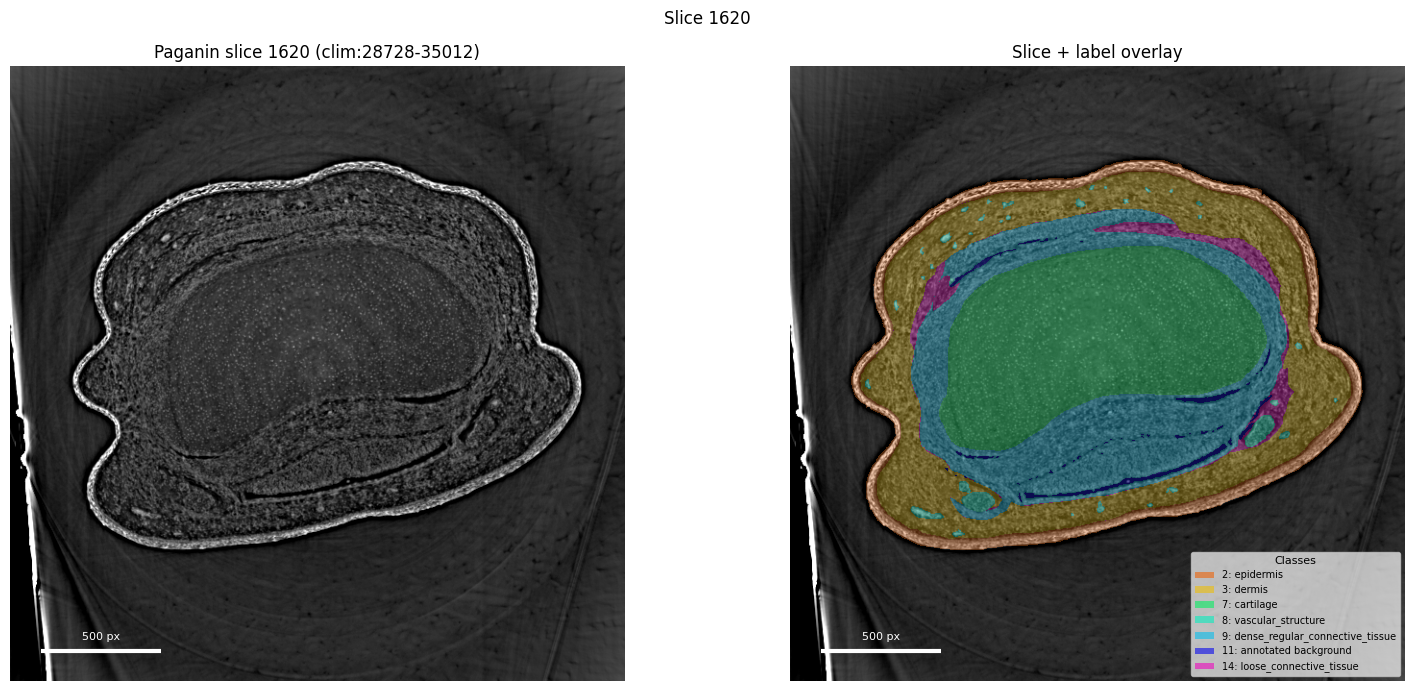

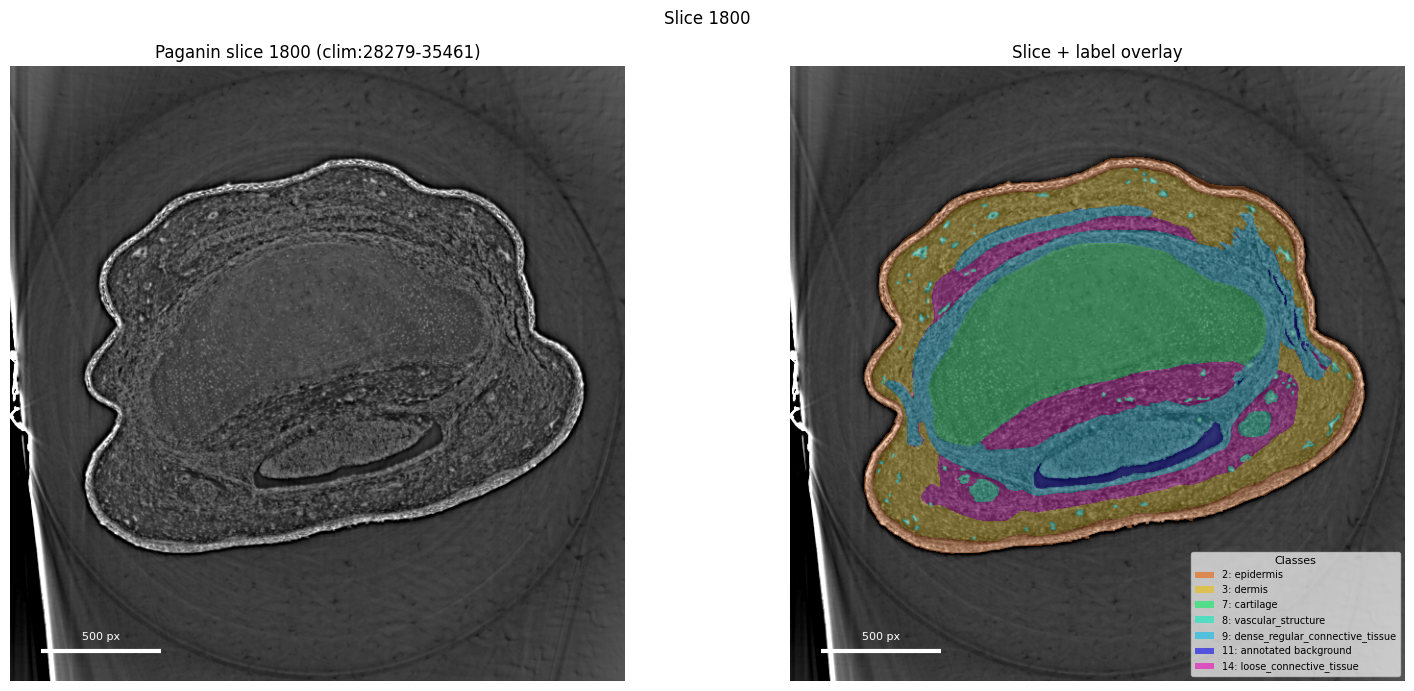

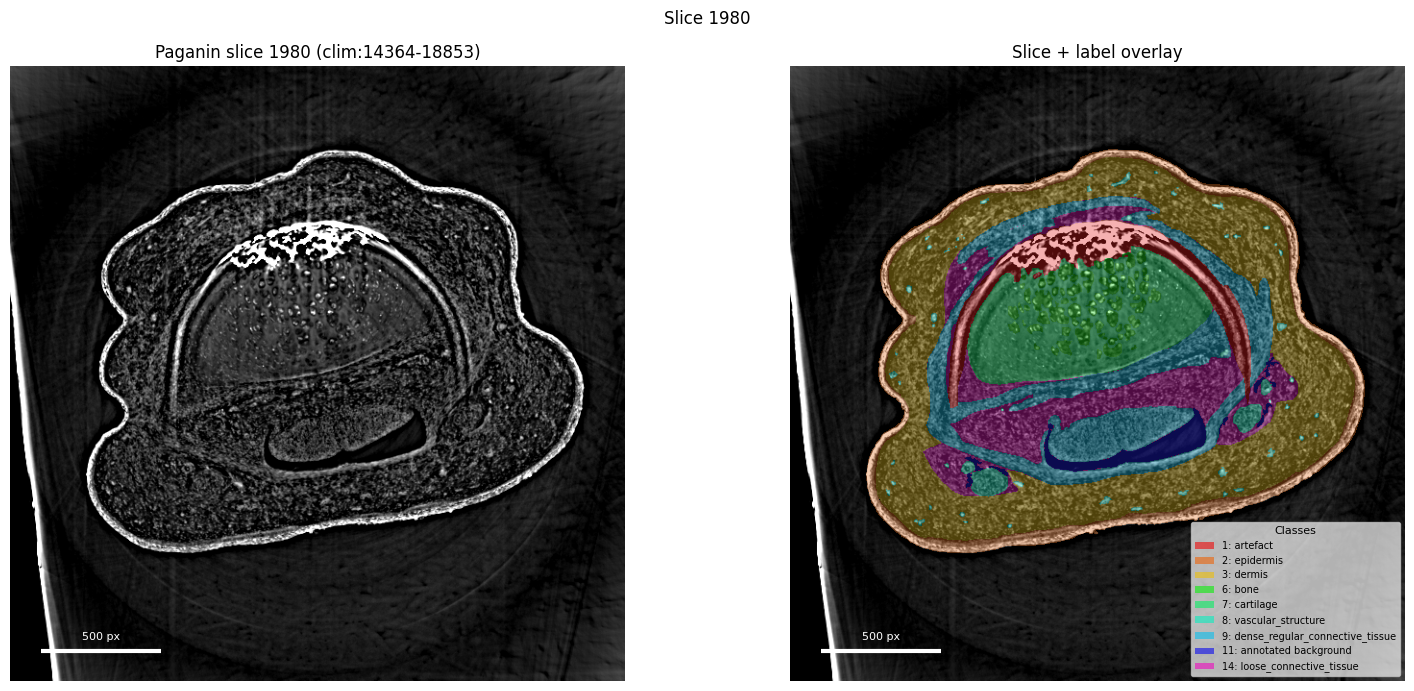

In [27]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path
from sdata_utils import class_id_colormap

# ── Find all annotated slices in OUT_DIR ────────────────────────────────────
saved_masks = sorted(OUT_DIR.glob(f"{SAMPLE_ID}_slice*_labels_from_shapes.npy"))

n_cls = max(CLASS_LABELS.keys())
cmap_dict = class_id_colormap(n_cls)
colors_list = [cmap_dict.get(i, (0, 0, 0, 0)) for i in range(n_cls + 1)]
cmap = mcolors.ListedColormap(colors_list)
norm = mcolors.BoundaryNorm(boundaries=range(n_cls + 2), ncolors=n_cls + 1)

for mask_path in saved_masks:
    import re
    slice_idx = int(re.search(r"slice(\d+)", mask_path.name).group(1))

    img_path = OUT_DIR / f"{SAMPLE_ID}_slice{slice_idx:04d}_u16.npy"
    cl_path  = OUT_DIR / f"{SAMPLE_ID}_slice{slice_idx:04d}_contrast_limits.json"

    mask_full = np.load(mask_path)           # (2560, 2560)
    img_full  = np.load(img_path)            # (2560, 2560) uint16

    # Downsample 4x for display speed (matches scale2 in the notebook)
    mask_small = mask_full[::4, ::4]
    img_small  = img_full[::4, ::4]

    # Contrast limits from saved JSON
    clim = None
    if cl_path.exists():
        with open(cl_path) as fh:
            meta = json.load(fh)
        lo_u16, hi_u16 = meta["contrast_limits_u16"]["paganin"]
        clim = (lo_u16, hi_u16)

    # Scale bar (px_um * 4 because we downsampled 4x)
    px_um_display = PIXEL_SIZE_UM * 4
    scalebar_um = 500
    scalebar_px = scalebar_um / px_um_display
    h, w = img_small.shape
    bar_x, bar_y = w * 0.05, h * 0.95

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"Slice {slice_idx:04d}", fontsize=12)

    for ax in axes:
        ax.imshow(img_small, cmap="gray",
                  vmin=clim[0] if clim else None,
                  vmax=clim[1] if clim else None)
        ax.plot([bar_x, bar_x + scalebar_px], [bar_y, bar_y],
                color="white", linewidth=3, solid_capstyle="butt")
        ax.text(bar_x + scalebar_px / 2, bar_y - h * 0.015,
                f"{scalebar_um} px", color="white", fontsize=8,
                ha="center", va="bottom")
        ax.axis("off")

    axes[0].set_title(f"Paganin slice {slice_idx:04d}" +
                      (f" (clim:{clim[0]:.0f}-{clim[1]:.0f})" if clim else ""))

    axes[1].imshow(mask_small, cmap=cmap, norm=norm, alpha=0.5,
                   interpolation="nearest")
    axes[1].set_title("Slice + label overlay")

    present_ids = [cid for cid in np.unique(mask_small) if cid != 0 and cid in CLASS_LABELS]
    legend_handles = [
        mpatches.Patch(facecolor=cmap_dict[cid][:3], alpha=cmap_dict[cid][3],
                       edgecolor="none", label=f"{cid}: {CLASS_LABELS[cid]}")
        for cid in present_ids
    ]
    if legend_handles:
        axes[1].legend(handles=legend_handles, loc="lower right", fontsize=7,
                       framealpha=0.7, title="Classes", title_fontsize=8)

    plt.tight_layout()
    plt.show()
